**Import Libraries**

In [127]:
import cv2
import mediapipe as mp
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
import os
import json

mp_hands = mp.solutions.hands
mp_drawing = mp.solutions.drawing_utils

print("Libraries imported successfully!")

Libraries imported successfully!


**Define Gesture Classes**

In [73]:
GESTURE_CLASSES = {
    0: 'fist',
    1: 'open_palm',
    2: 'thumbs_up',
    3: 'peace',
    4: 'pointing',
    5: 'ok_sign'
}

print("Gesture Classes:")
for idx, name in GESTURE_CLASSES.items():
    print(f"  {idx}: {name}")

Gesture Classes:
  0: fist
  1: open_palm
  2: thumbs_up
  3: peace
  4: pointing
  5: ok_sign


**Extract features from hand landmarks**

In [76]:
class HandFeatureExtractor:
    
    def __init__(self):
        self.finger_tips = [4, 8, 12, 16, 20]
        self.finger_pips = [2, 6, 10, 14, 18]
        self.finger_mcps = [1, 5, 9, 13, 17]
        
    def extract_features(self, hand_landmarks) -> np.ndarray:
        landmarks = self._get_landmark_array(hand_landmarks)
        normalized = self._normalize_landmarks(landmarks)
        distances = self._calculate_distances(landmarks)
        angles = self._calculate_angles(landmarks)
        finger_states = self._get_finger_states(landmarks)
        
        features = np.concatenate([
            normalized.flatten(),
            distances,
            angles,
            finger_states
        ])
        return features
    
    def _get_landmark_array(self, hand_landmarks) -> np.ndarray:
        return np.array([[lm.x, lm.y] for lm in hand_landmarks.landmark])
    
    def _normalize_landmarks(self, landmarks: np.ndarray) -> np.ndarray:
        wrist = landmarks[0]
        normalized = landmarks - wrist
        hand_size = np.max(np.linalg.norm(normalized, axis=1))
        if hand_size > 0:
            normalized = normalized / hand_size
        return normalized
    
    def _calculate_distances(self, landmarks: np.ndarray) -> np.ndarray:
        wrist = landmarks[0]
        distances = [np.linalg.norm(landmarks[tip] - wrist) for tip in self.finger_tips]
        return np.array(distances)
    
    def _calculate_angles(self, landmarks: np.ndarray) -> np.ndarray:
        angles = []
        for tip, pip, mcp in zip(self.finger_tips, self.finger_pips, self.finger_mcps):
            v1 = landmarks[pip] - landmarks[mcp]
            v2 = landmarks[tip] - landmarks[pip]
            cos_angle = np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2) + 1e-6)
            angle = np.degrees(np.arccos(np.clip(cos_angle, -1, 1)))
            angles.append(angle)
        return np.array(angles)
    
    def _get_finger_states(self, landmarks: np.ndarray) -> np.ndarray:
        wrist = landmarks[0]
        states = []
        for tip, pip in zip(self.finger_tips, self.finger_pips):
            tip_dist = np.linalg.norm(landmarks[tip] - wrist)
            pip_dist = np.linalg.norm(landmarks[pip] - wrist)
            states.append(1 if tip_dist > pip_dist * 1.1 else 0)
        return np.array(states)

feature_extractor = HandFeatureExtractor()

**Interactive Data Collection Tool**

In [92]:
class GestureDataCollector:
    
    def __init__(self, gesture_classes: dict, samples_per_gesture: int = 100):
        self.gesture_classes = gesture_classes
        self.samples_per_gesture = samples_per_gesture
        self.feature_extractor = HandFeatureExtractor()
        self.dataset = []
        
    def collect_data(self):
        """Run interactive data collection"""
        cap = cv2.VideoCapture(0)
        hands = mp_hands.Hands(
            static_image_mode=False,
            max_num_hands=2,  # <-- Change to 2 hands
            min_detection_confidence=0.7
        )
        
        print("GESTURE DATA COLLECTION")
        print("\nInstructions:")
        print("  - Press number keys (0-5) to select gesture")
        print("  - Press SPACE to start collecting samples")
        print("  - Press 'q' to quit\n")
        
        for idx, name in self.gesture_classes.items():
            print(f"  {idx}: {name.upper()}")
        print()
        
        current_gesture = None
        collecting = False
        samples_collected = 0
        
        while cap.isOpened():
            ret, frame = cap.read()
            if not ret:
                break
            
            frame = cv2.flip(frame, 1)
            h, w, _ = frame.shape
            rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            results = hands.process(rgb_frame)
            
            # UI Background
            cv2.rectangle(frame, (10, 10), (w-10, 120), (0, 0, 0), -1)
            
            # Display current gesture
            if current_gesture is not None:
                gesture_name = self.gesture_classes[current_gesture].upper()
                cv2.putText(frame, f"Gesture: {gesture_name}", (20, 40),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 255, 255), 2)
            else:
                cv2.putText(frame, "Select gesture (0-5)", (20, 40),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 255, 255), 2)
            
            # Display collection status
            if collecting:
                cv2.putText(frame, f"Collecting: {samples_collected}/{self.samples_per_gesture}",
                            (20, 80), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)
            else:
                cv2.putText(frame, "Press SPACE to collect", (20, 80),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)
            
            # Process hand detection
            if results.multi_hand_landmarks:
                for hand_landmarks in results.multi_hand_landmarks:
                    # Draw landmarks
                    mp_drawing.draw_landmarks(frame, hand_landmarks, mp_hands.HAND_CONNECTIONS)
                    
                    # Collect sample if in collection mode
                    if collecting and current_gesture is not None:
                        features = self.feature_extractor.extract_features(hand_landmarks)
                        self.dataset.append({
                            'features': features,
                            'label': current_gesture,
                            'gesture_name': self.gesture_classes[current_gesture]
                        })
                        samples_collected += 1
                        
                        # Stop collecting when target reached
                        if samples_collected >= self.samples_per_gesture:
                            collecting = False
                            samples_collected = 0
                            print(f"Collected {self.samples_per_gesture} samples for {self.gesture_classes[current_gesture]}")
            
            cv2.imshow('Gesture Data Collection', frame)
            
            # Handle key presses
            key = cv2.waitKey(1) & 0xFF
            
            # Select gesture (0-5)
            if key in [ord(str(i)) for i in range(6)]:
                current_gesture = int(chr(key))
                collecting = False
                samples_collected = 0
                print(f"\nSelected gesture: {self.gesture_classes[current_gesture].upper()}")
            
            # Start/stop collection
            elif key == ord(' '):
                if current_gesture is not None:
                    collecting = not collecting
                    if collecting:
                        print("Collecting samples.....")
                    else:
                        print("Collection paused")
            
            # Quit
            elif key == ord('q'):
                break
        
        cap.release()
        cv2.destroyAllWindows()
        hands.close()
        
        print(f"\nData collection complete! Total samples: {len(self.dataset)}")
        return self.dataset
    
    def save_dataset(self, filepath: str = '../data/raw/gesture_dataset.npz'):
        """Save collected dataset"""
        if not self.dataset:
            print("No data to save!")
            return
        
        # Convert to arrays
        features = np.array([sample['features'] for sample in self.dataset])
        labels = np.array([sample['label'] for sample in self.dataset])
        
        # Save
        os.makedirs(os.path.dirname(filepath), exist_ok=True)
        np.savez(filepath, features=features, labels=labels)
        
        # Save metadata
        metadata = {
            'gesture_classes': self.gesture_classes,
            'num_samples': len(self.dataset),
            'num_features': features.shape[1],
            'collection_date': datetime.now().strftime('%Y-%m-%d %H:%M:%S')
        }
        
        metadata_path = filepath.replace('.npz', '_metadata.json')
        with open(metadata_path, 'w') as f:
            json.dump(metadata, f, indent=4)
        
        print(f"Dataset saved to: {filepath}")
        print(f"Shape: {features.shape}")

**Collect the Dataset**

In [105]:
# Initialize collector
collector = GestureDataCollector(
    gesture_classes=GESTURE_CLASSES,
    samples_per_gesture=100
)

# Run collection
dataset = collector.collect_data()

# Save dataset
collector.save_dataset('../data/raw/gesture_dataset.npz')

GESTURE DATA COLLECTION

Instructions:
  - Press number keys (0-5) to select gesture
  - Press SPACE to start collecting samples
  - Press 'q' to quit

  0: FIST
  1: OPEN_PALM
  2: THUMBS_UP
  3: PEACE
  4: POINTING
  5: OK_SIGN



I0000 00:00:1766733299.741844       1 gl_context.cc:344] GL version: 2.1 (2.1 Metal - 89.4), renderer: Apple M2



Selected gesture: FIST
Collected 100 samples for fist

Selected gesture: OPEN_PALM
Collected 100 samples for open_palm

Selected gesture: THUMBS_UP
Collected 100 samples for thumbs_up

Selected gesture: POINTING
Collected 100 samples for pointing

Selected gesture: OK_SIGN
Collected 100 samples for ok_sign

Data collection complete! Total samples: 500
Dataset saved to: ../data/raw/gesture_dataset.npz
Shape: (500, 57)


**Load and Visualize Dataset**

In [121]:
def load_and_visualize_dataset(filepath: str = '../data/raw/gesture_dataset.npz'):
    """Load and visualize the collected dataset"""
    
    # Load data
    data = np.load(filepath)
    features = data['features']
    labels = data['labels']
    
    # Load gesture classes from metadata
    with open(filepath.replace('.npz', '_metadata.json'), 'r') as f:
        gesture_classes = json.load(f)['gesture_classes']
    
    print(f"Dataset loaded!")
    print(f"  Features shape: {features.shape}")
    print(f"  Labels shape: {labels.shape}")
    
    # Class distribution
    unique, counts = np.unique(labels, return_counts=True)
    
    plt.figure(figsize=(12, 5))
    
    # Plot 1: Class distribution
    plt.subplot(1, 2, 1)
    gesture_names = [gesture_classes[str(i)] for i in unique]
    colors = plt.cm.Set3(np.linspace(0, 1, len(unique)))
    plt.bar(gesture_names, counts, color=colors, alpha=0.8, edgecolor='black')
    plt.xlabel('Gesture Class')
    plt.ylabel('Number of Samples')
    plt.title('Dataset Distribution')
    plt.xticks(rotation=45, ha='right')
    
    # Plot 2: Feature statistics
    plt.subplot(1, 2, 2)
    feature_means = features.mean(axis=0)
    plt.plot(feature_means, marker='o', markersize=2, alpha=0.6)
    plt.xlabel('Feature Index')
    plt.ylabel('Mean Value')
    plt.title('Feature Statistics (Mean per feature)')
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Print summary
    print(f"\n Dataset Summary:")
    for i, count in zip(unique, counts):
        print(f"  {gesture_classes[str(i)]}: {count} samples")

Dataset loaded!
  Features shape: (500, 57)
  Labels shape: (500,)


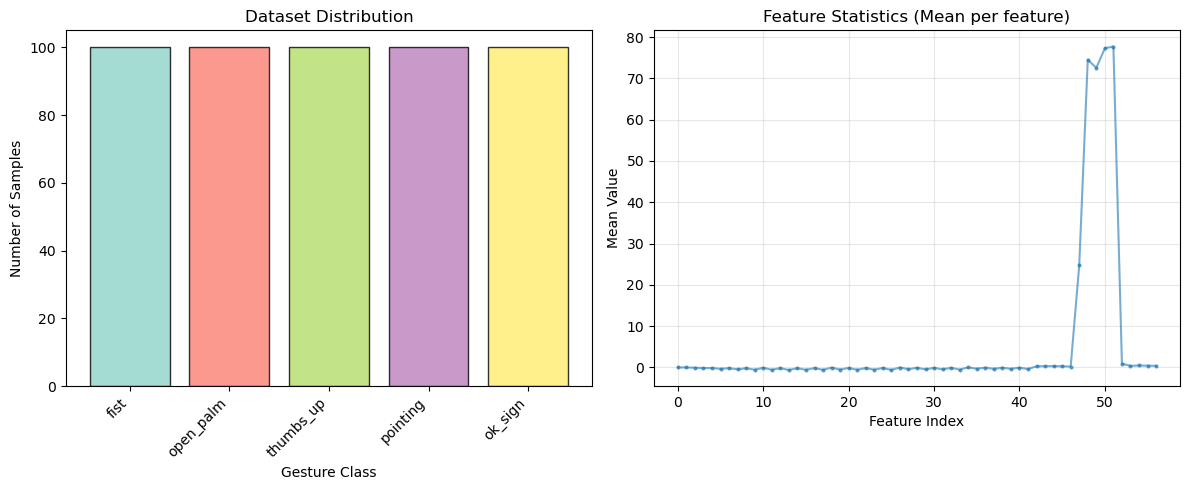


 Dataset Summary:
  fist: 100 samples
  open_palm: 100 samples
  thumbs_up: 100 samples
  pointing: 100 samples
  ok_sign: 100 samples


In [123]:
load_and_visualize_dataset('../data/raw/gesture_dataset.npz')